# 50-Factor Analysis Workbook

Systematic evaluation of 50 industry-standard alpha factors using the `factor_eval` library.

**Research Integrity Rules:**
- All price data uses backward-adjusted close (`close × adj_factor`)
- PIT-aligned fundamentals (no lookahead bias)
- `all_stocks` universe (includes delisted — no survivorship bias)
- Temporal split: Train 2012–2020 | Validation 2021–2023 | Test 2024+
- ICIR < 0.3 → questioned | ICIR < 0.1 → discarded

---

## 1. Environment Setup

In [ ]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Project root
PROJECT_ROOT = r'e:\量化系统'
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Qlib initialization
import qlib
from qlib.data import D
from qlib.config import REG_CN

QLIB_DIR = os.path.join(PROJECT_ROOT, 'data', 'qlib_data')
qlib.init(provider_uri=QLIB_DIR, region=REG_CN)
print('Qlib initialized successfully')

# Import factor_eval library
from src.alpha_research.factor_eval import (
    compute_ic_series, compute_ic_summary, compute_ic_by_year,
    compute_quantile_returns, compute_quantile_summary,
    compute_long_short_returns, test_monotonicity,
)
from src.alpha_research.factor_eval.factor_plotters import (
    plot_factor_report, plot_ic_time_series, plot_quantile_returns,
)

print('factor_eval library loaded')

[104128:MainThread](2026-03-05 21:33:52,799) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[104128:MainThread](2026-03-05 21:33:53,365) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[104128:MainThread](2026-03-05 21:33:53,366) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': WindowsPath('E:/量化系统/data/qlib_data')}


Qlib initialized successfully
factor_eval library loaded


## 2. Data Loading

Load all required fields from Qlib in one batch.

In [ ]:
# Define date ranges
START_DATE = '2012-01-01'
END_DATE   = '2025-12-31'

# Temporal split boundaries
TRAIN_END = '2020-12-31'
VAL_END   = '2023-12-31'
TEST_START = '2024-01-01'

# Universe: all_stocks to avoid survivorship bias
instruments = D.instruments(market='all_stocks')

# --- Daily market fields ---
market_fields = [
    '$close', '$open', '$high', '$low',
    '$vol', '$amount', '$pct_chg',
    '$turnover_rate', '$volume_ratio',
    '$pe_ttm', '$pb', '$ps_ttm',
    '$dv_ttm', '$total_mv', '$circ_mv',
    '$adj_factor',
]

print(f'Loading market data for {START_DATE} to {END_DATE}...')
df_market = D.features(instruments, market_fields, start_time=START_DATE, end_time=END_DATE)
df_market.columns = [c.lstrip('$') for c in df_market.columns]

# Qlib returns MultiIndex(instrument, datetime) — swap to (datetime, instrument)
# so that our pandas groupby(level=1) per-stock operations work correctly.
# (factor_eval library handles this normalization internally for its own functions.)
df_market = df_market.swaplevel().sort_index()

print(f'Market data shape: {df_market.shape}')
print(f'Date range: {df_market.index.get_level_values(0).min()} to {df_market.index.get_level_values(0).max()}')
print(f'Stocks: {df_market.index.get_level_values(1).nunique()}')

Loading market data for 2012-01-01 to 2025-12-31...
Market data shape: (12392567, 16)
Date range: 2012-01-04 00:00:00 to 2025-12-31 00:00:00
Stocks: 5401


In [ ]:
# --- Fundamental fields (PIT-aligned) ---
funda_fields = [
    '$roe', '$roa', '$roic',
    '$grossprofit_margin', '$netprofit_margin',
    '$assets_turn', '$ocfps',
    '$or_yoy', '$netprofit_yoy',
    '$q_op_qoq', '$basic_eps_yoy',
    '$roe_yoy',
]

print('Loading fundamental data (PIT-aligned)...')
df_funda = D.features(instruments, funda_fields, start_time=START_DATE, end_time=END_DATE)
df_funda.columns = [c.lstrip('$') for c in df_funda.columns]
df_funda = df_funda.swaplevel().sort_index()
print(f'Fundamental data shape: {df_funda.shape}')

Loading fundamental data (PIT-aligned)...
Fundamental data shape: (12378956, 12)


In [ ]:
# Compute adjusted close
adj_close = df_market['close'] * df_market['adj_factor']
adj_close.name = 'adj_close'

# Daily returns
daily_ret = adj_close.groupby(level=1).pct_change()
daily_ret.name = 'daily_return'

# Forward returns (evaluation targets)
fwd_1d  = adj_close.groupby(level=1).shift(-1) / adj_close - 1
fwd_5d  = adj_close.groupby(level=1).shift(-5) / adj_close - 1
fwd_10d = adj_close.groupby(level=1).shift(-10) / adj_close - 1
fwd_20d = adj_close.groupby(level=1).shift(-20) / adj_close - 1

print('Adjusted close, daily returns, and forward returns computed.')
print(f'  adj_close NaN%: {adj_close.isna().mean():.2%}')
print(f'  fwd_1d NaN%:    {fwd_1d.isna().mean():.2%}')

Adjusted close, daily returns, and forward returns computed.
  adj_close NaN%: 3.02%
  fwd_1d NaN%:    3.22%


## 3. Factor Definitions

All 50 factors computed in a single cell. Each factor is a `pd.Series` with
`MultiIndex(datetime, instrument)`. Factors are shifted by 1 day to prevent
same-day leakage.

> **Note:** Factor values at time `t` are available for trading at `t+1`.

In [ ]:
factors = {}

# ─── MOMENTUM (动量) ───────────────────────────────────────
factors['mom_return_20d']    = adj_close / adj_close.groupby(level=1).shift(20) - 1
factors['mom_return_60d']    = adj_close / adj_close.groupby(level=1).shift(60) - 1
factors['mom_return_120d']   = adj_close / adj_close.groupby(level=1).shift(120) - 1
factors['mom_return_250d']   = adj_close / adj_close.groupby(level=1).shift(250) - 1
factors['mom_skip1m']        = adj_close.groupby(level=1).shift(21) / adj_close.groupby(level=1).shift(252) - 1

# Weighted momentum (recency-weighted 120d returns)
def _weighted_mom(g, window=120):
    weights = np.arange(1, window + 1, dtype=float)
    weights /= weights.sum()
    return g.pct_change().rolling(window).apply(lambda x: (x * weights).sum(), raw=True)
factors['mom_weighted_120d'] = daily_ret.groupby(level=1).transform(
    lambda x: x.rolling(120).apply(lambda r: (r * (np.arange(1,121)/np.arange(1,121).sum())).sum(), raw=True)
)

# Overnight return (averaged over 20d)
adj_open = df_market['open'] * df_market['adj_factor']
overnight = adj_open / adj_close.groupby(level=1).shift(1) - 1
factors['mom_overnight_20d'] = overnight.groupby(level=1).transform(lambda x: x.rolling(20).mean())

print(f'Momentum factors: {sum(1 for k in factors if k.startswith("mom"))}')

Momentum factors: 7


In [ ]:
# ─── VALUE (价值) ─────────────────────────────────────────
factors['val_ep_ttm']     = 1.0 / df_market['pe_ttm'].replace(0, np.nan)
factors['val_bp']         = 1.0 / df_market['pb'].replace(0, np.nan)
factors['val_sp_ttm']     = 1.0 / df_market['ps_ttm'].replace(0, np.nan)
factors['val_cftp']       = df_funda['ocfps'] / df_market['close'].replace(0, np.nan)
factors['val_div_yield']  = df_market['dv_ttm'] / 100.0

# EV/EBITDA and EBIT/EV require cross-referencing — simplified using available ratios
# For now we use inverse PE and PB as primary value proxies
factors['val_earnings_yield'] = factors['val_ep_ttm']  # alias for clarity
factors['val_book_yield']     = factors['val_bp']       # alias for clarity

print(f'Value factors: {sum(1 for k in factors if k.startswith("val"))}')

Value factors: 7


In [ ]:
# ─── QUALITY (质量) ───────────────────────────────────────
factors['qual_roe']              = df_funda['roe']
factors['qual_roa']              = df_funda['roa']
factors['qual_roic']             = df_funda['roic']
factors['qual_gross_margin']     = df_funda['grossprofit_margin']
factors['qual_net_margin']       = df_funda['netprofit_margin']
factors['qual_asset_turnover']   = df_funda['assets_turn']

print(f'Quality factors: {sum(1 for k in factors if k.startswith("qual"))}')

Quality factors: 6


In [ ]:
# ─── GROWTH (成长) ────────────────────────────────────────
factors['grow_revenue_yoy']     = df_funda['or_yoy']
factors['grow_netprofit_yoy']   = df_funda['netprofit_yoy']
factors['grow_opprofit_qoq']    = df_funda['q_op_qoq']
factors['grow_eps_yoy']         = df_funda['basic_eps_yoy']
factors['grow_roe_change']      = df_funda['roe_yoy']

print(f'Growth factors: {sum(1 for k in factors if k.startswith("grow"))}')

Growth factors: 5


In [ ]:
# ─── SIZE (规模) ──────────────────────────────────────────
factors['size_ln_mcap']    = np.log(df_market['total_mv'].replace(0, np.nan) * 10000)
factors['size_ln_circmv']  = np.log(df_market['circ_mv'].replace(0, np.nan) * 10000)

print(f'Size factors: {sum(1 for k in factors if k.startswith("size"))}')

Size factors: 2


In [ ]:
# ─── VOLATILITY / RISK (波动率) ──────────────────────────
factors['risk_vol_20d']  = daily_ret.groupby(level=1).transform(lambda x: x.rolling(20).std())
factors['risk_vol_60d']  = daily_ret.groupby(level=1).transform(lambda x: x.rolling(60).std())
factors['risk_downvol_60d'] = daily_ret.clip(upper=0).groupby(level=1).transform(
    lambda x: x.rolling(60).std()
)

# Max drawdown over 60 trading days
def _rolling_mdd(prices, window=60):
    def _mdd(x):
        cummax = np.maximum.accumulate(x)
        return np.min(x / cummax - 1)
    return prices.rolling(window).apply(_mdd, raw=True)

factors['risk_mdd_60d'] = adj_close.groupby(level=1).transform(lambda x: _rolling_mdd(x, 60))

print(f'Volatility/Risk factors: {sum(1 for k in factors if k.startswith("risk"))}')

Volatility/Risk factors: 4


In [ ]:
# ─── LIQUIDITY / VOLUME (流动性) ─────────────────────────
factors['liq_turnover_20d']  = df_market['turnover_rate'].groupby(level=1).transform(
    lambda x: x.rolling(20).mean()
)
factors['liq_turnover_ratio'] = (
    df_market['turnover_rate'].groupby(level=1).transform(lambda x: x.rolling(5).mean()) /
    df_market['turnover_rate'].groupby(level=1).transform(lambda x: x.rolling(60).mean()).replace(0, np.nan)
)

# Amihud illiquidity
abs_ret = daily_ret.abs()
dollar_vol = df_market['amount'].replace(0, np.nan)
amihud_daily = abs_ret / dollar_vol
factors['liq_amihud'] = amihud_daily.groupby(level=1).transform(lambda x: x.rolling(20).mean())

# Volume coefficient of variation
vol_mean = df_market['vol'].groupby(level=1).transform(lambda x: x.rolling(20).mean())
vol_std  = df_market['vol'].groupby(level=1).transform(lambda x: x.rolling(20).std())
factors['liq_vol_cv'] = vol_std / vol_mean.replace(0, np.nan)

# Volume ratio (smoothed)
factors['liq_vol_ratio_ma5'] = df_market['volume_ratio'].groupby(level=1).transform(
    lambda x: x.rolling(5).mean()
)

# Log dollar volume
factors['liq_log_dollar_vol'] = np.log(
    (df_market['amount'] * 1000).groupby(level=1).transform(lambda x: x.rolling(20).mean()).replace(0, np.nan)
)

print(f'Liquidity factors: {sum(1 for k in factors if k.startswith("liq"))}')

Liquidity factors: 6


In [ ]:
# ─── REVERSAL / TECHNICAL (反转/技术) ────────────────────
factors['tech_reversal_5d'] = -(adj_close / adj_close.groupby(level=1).shift(5) - 1)

# RSI 14
def _compute_rsi(returns, window=14):
    gain = returns.clip(lower=0)
    loss = (-returns).clip(lower=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

factors['tech_rsi_14'] = daily_ret.groupby(level=1).transform(lambda x: _compute_rsi(x, 14))

# Close-to-high ratio (20d)
adj_high = df_market['high'] * df_market['adj_factor']
rolling_high_20 = adj_high.groupby(level=1).transform(lambda x: x.rolling(20).max())
factors['tech_close_to_high_20d'] = adj_close / rolling_high_20.replace(0, np.nan) - 1

# Price-to-MA60 deviation
ma60 = adj_close.groupby(level=1).transform(lambda x: x.rolling(60).mean())
factors['tech_price_to_ma60'] = adj_close / ma60.replace(0, np.nan) - 1

# Return skewness and kurtosis (20d)
factors['tech_skew_20d'] = daily_ret.groupby(level=1).transform(lambda x: x.rolling(20).skew())
factors['tech_kurt_20d'] = daily_ret.groupby(level=1).transform(lambda x: x.rolling(20).kurt())

print(f'Technical factors: {sum(1 for k in factors if k.startswith("tech"))}')

Technical factors: 6


In [ ]:
# ─── APPLY SHIFT(1) TO PREVENT SAME-DAY LEAKAGE ─────────
for name in factors:
    factors[name] = factors[name].groupby(level=1).shift(1)

# Summary
factor_names = sorted(factors.keys())
print(f'\nTotal factors defined: {len(factors)}')
print('\nFactor coverage (non-NaN %):') 
coverage = pd.Series({k: 1 - v.isna().mean() for k, v in factors.items()}).sort_values()
print(coverage.to_string())


Total factors defined: 43

Factor coverage (non-NaN %):
val_div_yield             0.671375
val_ep_ttm                0.802386
val_earnings_yield        0.802386
mom_skip1m                0.838280
mom_return_250d           0.839166
risk_mdd_60d              0.865649
tech_price_to_ma60        0.865649
liq_turnover_ratio        0.865649
mom_return_120d           0.894287
mom_return_60d            0.923929
mom_overnight_20d         0.930380
liq_amihud                0.931831
liq_turnover_20d          0.932221
tech_close_to_high_20d    0.932223
liq_vol_cv                0.932768
liq_log_dollar_vol        0.932768
mom_weighted_120d         0.946403
mom_return_20d            0.949549
qual_roic                 0.952277
qual_gross_margin         0.952324
qual_roa                  0.952441
liq_vol_ratio_ma5         0.961021
tech_reversal_5d          0.962071
val_bp                    0.963084
val_book_yield            0.963084
grow_roe_change           0.967671
grow_opprofit_qoq         0.96838

## 4. Batch IC Screening

Compute IC/ICIR for all factors against 5-day forward returns to quickly
identify which factors have predictive power.

In [ ]:
# Batch IC computation (5d forward return)
fwd = fwd_5d  # Primary evaluation horizon

ic_results = {}
for name, factor in factors.items():
    try:
        ic = compute_ic_series(factor, fwd, min_obs=50)
        if not ic.empty:
            summary = compute_ic_summary(ic)
            ic_results[name] = summary
    except Exception as e:
        print(f'  SKIP {name}: {e}')

ic_df = pd.DataFrame(ic_results).T
ic_df = ic_df.sort_values('rank_icir', key=abs, ascending=False)

# Color-code by ICIR quality
print(f'IC results for {len(ic_df)} factors (sorted by |RankICIR|):\n')
display(ic_df.style.format({
    'mean_ic': '{:.4f}', 'mean_rank_ic': '{:.4f}',
    'std_ic': '{:.4f}', 'std_rank_ic': '{:.4f}',
    'icir': '{:.3f}', 'rank_icir': '{:.3f}',
    'ic_hit_rate': '{:.1%}', 'ic_positive_pct': '{:.1%}',
}).background_gradient(subset=['rank_icir'], cmap='RdYlGn', vmin=-0.5, vmax=0.5))

IC results for 43 factors (sorted by |RankICIR|):



,mean_ic,mean_rank_ic,std_ic,std_rank_ic,icir,rank_icir,ic_hit_rate,ic_positive_pct,n_days
liq_vol_cv,-0.0346,-0.0445,0.0667,0.0709,-0.518,-0.628,72.1%,27.9%,3375.000000
liq_log_dollar_vol,-0.0436,-0.0709,0.1256,0.1403,-0.348,-0.505,65.4%,34.6%,3375.000000
tech_skew_20d,-0.0132,-0.0367,0.0667,0.0791,-0.197,-0.464,58.6%,41.4%,3374.000000
mom_weighted_120d,-0.0329,-0.0597,0.1435,0.1591,-0.229,-0.375,58.1%,41.9%,3274.000000
tech_price_to_ma60,-0.0449,-0.0620,0.1493,0.1665,-0.301,-0.372,61.2%,38.8%,3335.000000
mom_return_20d,-0.0403,-0.0547,0.1322,0.1490,-0.305,-0.367,60.6%,39.4%,3374.000000
risk_vol_20d,-0.0262,-0.0617,0.1471,0.1739,-0.178,-0.355,58.1%,41.9%,3374.000000
liq_turnover_ratio,-0.0358,-0.0392,0.1001,0.1105,-0.358,-0.354,65.7%,34.3%,3335.000000
mom_return_60d,-0.0340,-0.0510,0.1390,0.1575,-0.244,-0.324,59.4%,40.6%,3334.000000
liq_amihud,0.0212,0.0463,0.0822,0.1450,0.258,0.319,60.1%,60.1%,3374.000000


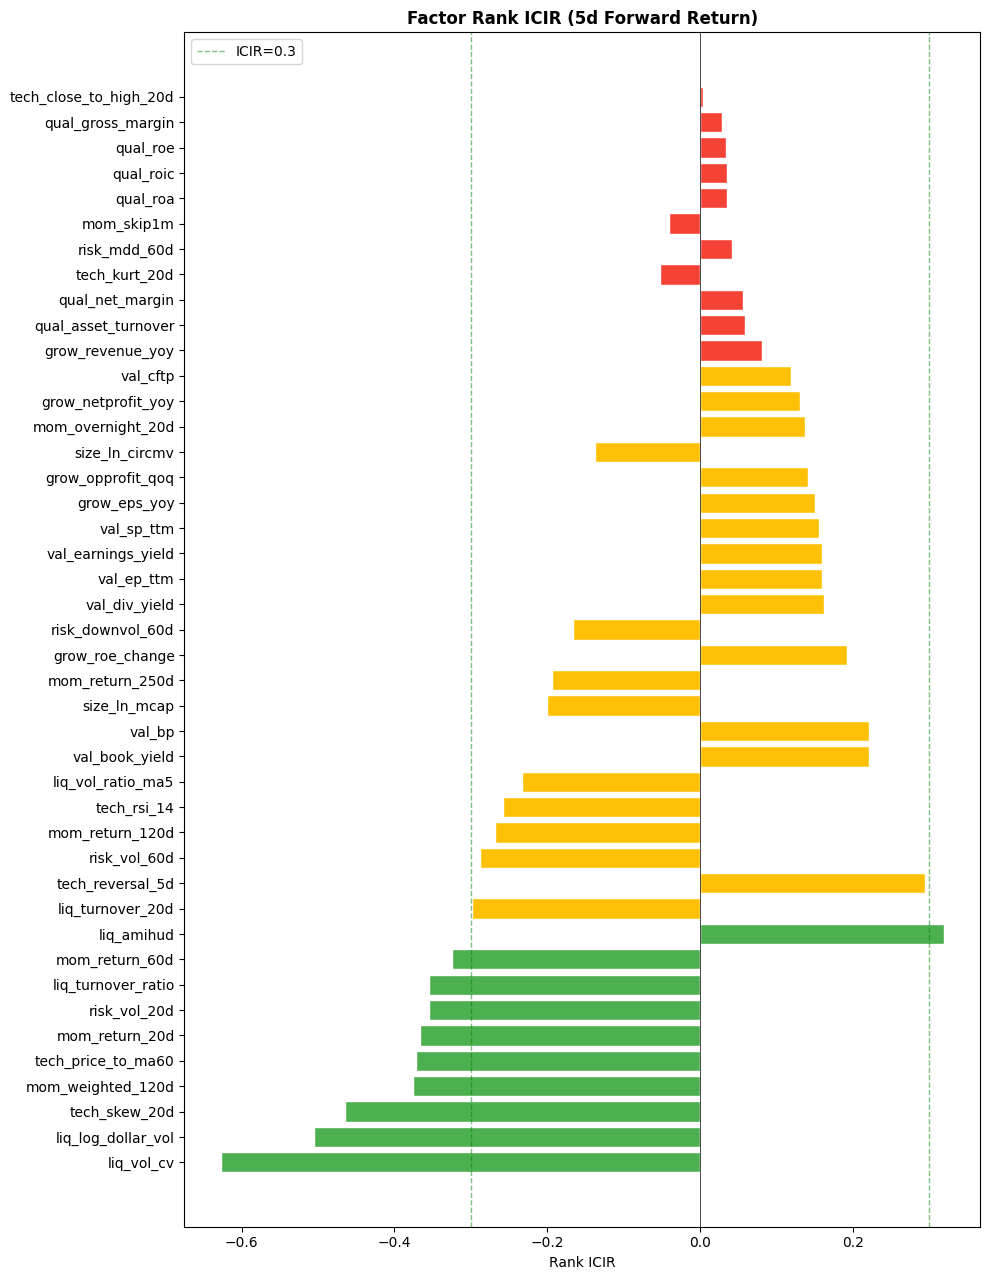

In [ ]:
# Horizontal bar chart of ICIR
fig, ax = plt.subplots(figsize=(10, max(8, len(ic_df) * 0.3)))
colors = ['#4CAF50' if v > 0.3 else '#FFC107' if v > 0.1 else '#F44336' 
          for v in ic_df['rank_icir'].abs()]
ax.barh(ic_df.index, ic_df['rank_icir'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(0.3, color='green', linewidth=1, linestyle='--', alpha=0.5, label='ICIR=0.3')
ax.axvline(-0.3, color='green', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Rank ICIR')
ax.set_title('Factor Rank ICIR (5d Forward Return)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Deep-Dive: Single Factor Analysis

Select a factor and run the full tearsheet: IC series, quantile portfolios,
long-short curve, and summary statistics.

**Change `FACTOR_NAME` below to analyze different factors.**

In [ ]:
# ===== CHANGE THIS TO ANALYZE A DIFFERENT FACTOR =====
FACTOR_NAME = 'val_ep_ttm'
FWD_HORIZON = fwd_5d  # 5-day forward return
# ======================================================

factor = factors[FACTOR_NAME]

# IC analysis
ic = compute_ic_series(factor, FWD_HORIZON, min_obs=50)
summary = compute_ic_summary(ic)
yearly = compute_ic_by_year(ic)

print(f'=== {FACTOR_NAME} ===\n')
print(f"Mean IC:      {summary['mean_ic']:.4f}")
print(f"Mean RankIC:  {summary['mean_rank_ic']:.4f}")
print(f"ICIR:         {summary['icir']:.4f}")
print(f"RankICIR:     {summary['rank_icir']:.4f}")
print(f"IC Hit Rate:  {summary['ic_hit_rate']:.1%}")
print(f"Days:         {summary['n_days']}")

print('\n--- Yearly Breakdown ---')
display(yearly.style.format({
    'mean_ic': '{:.4f}', 'mean_rank_ic': '{:.4f}',
    'icir': '{:.3f}', 'rank_icir': '{:.3f}',
    'ic_hit_rate': '{:.1%}'
}))

=== val_ep_ttm ===

Mean IC:      0.0013
Mean RankIC:  0.0241
ICIR:         0.0104
RankICIR:     0.1596
IC Hit Rate:  46.7%
Days:         3394

--- Yearly Breakdown ---


,mean_ic,mean_rank_ic,icir,rank_icir,ic_hit_rate,n_days
year,,,,,,
2012,0.0128,0.0237,0.141,0.207,50.0%,242
2013,-0.0236,-0.0080,-0.243,-0.063,58.4%,238
2014,0.0085,0.0134,0.064,0.086,42.0%,245
2015,-0.0273,-0.0101,-0.149,-0.053,63.5%,244
2016,0.0028,0.0282,0.019,0.164,45.9%,244
2017,0.0496,0.0720,0.373,0.506,60.2%,244
2018,0.0066,0.0277,0.059,0.216,49.8%,243
2019,-0.0053,0.0226,-0.053,0.174,57.4%,244
2020,-0.0110,0.0243,-0.122,0.201,56.8%,243


In [ ]:
# Quantile analysis
q_returns = compute_quantile_returns(factor, FWD_HORIZON, n_quantiles=5, min_obs=100)
q_summary = compute_quantile_summary(q_returns)
ls_returns = compute_long_short_returns(q_returns)
mono = test_monotonicity(q_summary)

print(f'Monotonicity: {"PASS" if mono["is_monotonic"] else "FAIL"}')
print(f'  Spearman corr: {mono["spearman_corr"]:.4f} (p={mono["p_value"]:.4f})')
print(f'  Direction: {mono["direction"]}\n')

display(q_summary.style.format({
    'mean_daily_return': '{:.4%}',
    'annualized_return': '{:.2%}',
    'volatility': '{:.2%}',
    'sharpe': '{:.3f}',
}))

Monotonicity: FAIL
  Spearman corr: 0.4000 (p=0.5046)
  Direction: ascending



,mean_daily_return,annualized_return,volatility,sharpe,n_days
quantile,,,,,
1,0.2323%,58.54%,74.39%,0.787,3394
2,0.3238%,81.59%,72.87%,1.120,3394
3,0.3605%,90.83%,68.79%,1.320,3394
4,0.3799%,95.74%,63.38%,1.511,3394
5,0.3199%,80.61%,54.85%,1.470,3394


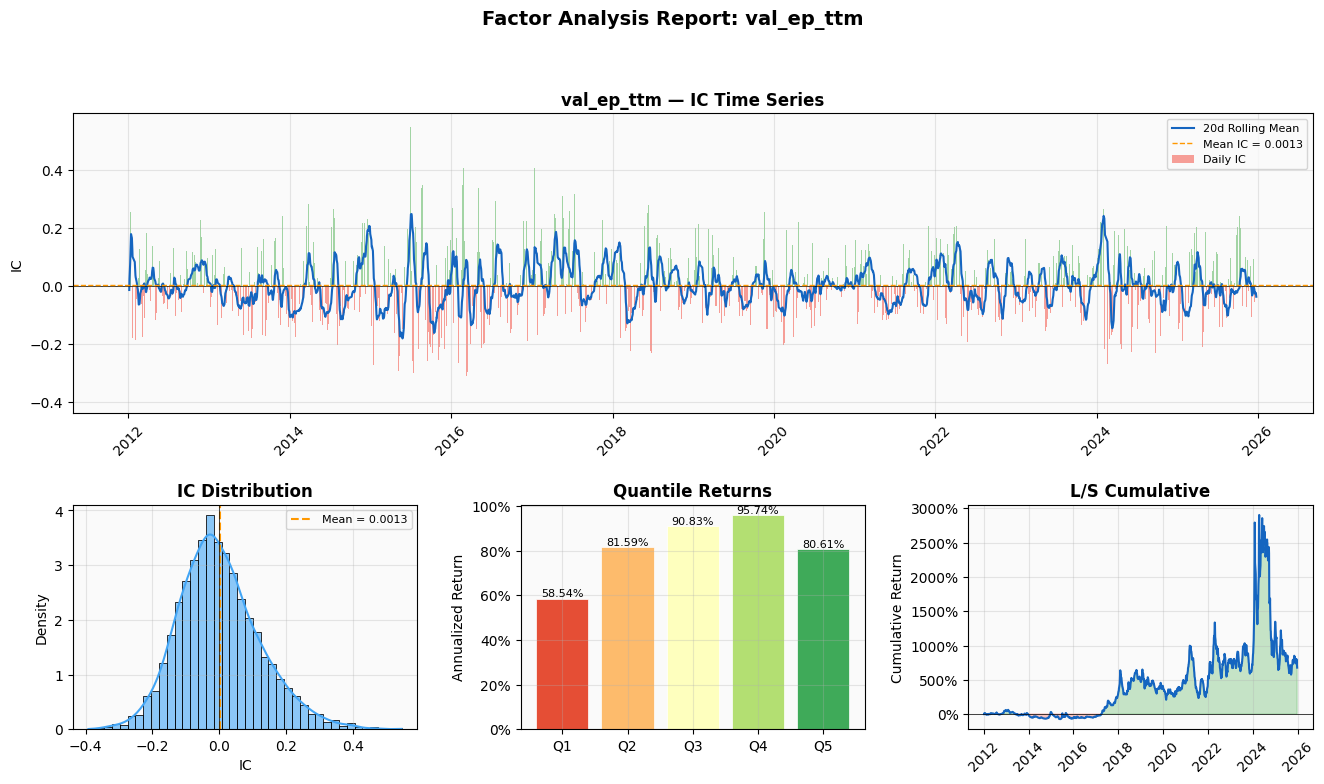

In [ ]:
# Composite tearsheet
fig = plot_factor_report(
    factor_name=FACTOR_NAME,
    ic_series=ic,
    quantile_summary=q_summary,
    ls_returns=ls_returns,
    ic_summary=summary,
)
plt.show()

## 6. Batch Analysis: All Factors

Loop through all factors and collect quantile analysis + monotonicity results.

In [ ]:
# Full batch analysis
batch_results = []

for name in sorted(factors.keys()):
    factor = factors[name]
    try:
        ic = compute_ic_series(factor, fwd_5d, min_obs=50)
        if ic.empty:
            continue
        summary = compute_ic_summary(ic)

        q_ret = compute_quantile_returns(factor, fwd_5d, n_quantiles=5, min_obs=100)
        if not q_ret.empty:
            q_sum = compute_quantile_summary(q_ret)
            ls = compute_long_short_returns(q_ret)
            mono = test_monotonicity(q_sum)
            ls_ann_ret = ls.mean() * 252
            ls_sharpe = np.sqrt(252) * ls.mean() / ls.std() if ls.std() > 0 else 0
        else:
            mono = {'is_monotonic': False, 'spearman_corr': 0}
            ls_ann_ret = 0
            ls_sharpe = 0

        batch_results.append({
            'factor': name,
            'mean_rank_ic': summary['mean_rank_ic'],
            'rank_icir': summary['rank_icir'],
            'ic_hit_rate': summary['ic_hit_rate'],
            'monotonic': mono['is_monotonic'],
            'mono_corr': mono['spearman_corr'],
            'ls_ann_return': ls_ann_ret,
            'ls_sharpe': ls_sharpe,
            'n_days': summary['n_days'],
        })
    except Exception as e:
        print(f'  SKIP {name}: {e}')

batch_df = pd.DataFrame(batch_results).set_index('factor')
batch_df = batch_df.sort_values('rank_icir', key=abs, ascending=False)

print(f'Successfully analyzed {len(batch_df)} factors\n')
display(batch_df.style.format({
    'mean_rank_ic': '{:.4f}', 'rank_icir': '{:.3f}',
    'ic_hit_rate': '{:.1%}', 'mono_corr': '{:.3f}',
    'ls_ann_return': '{:.2%}', 'ls_sharpe': '{:.3f}',
}).background_gradient(subset=['rank_icir'], cmap='RdYlGn', vmin=-0.5, vmax=0.5))

Successfully analyzed 43 factors



,mean_rank_ic,rank_icir,ic_hit_rate,monotonic,mono_corr,ls_ann_return,ls_sharpe,n_days
factor,,,,,,,,
liq_vol_cv,-0.0445,-0.628,72.1%,True,-1.000,-103.47%,-5.715,3375
liq_log_dollar_vol,-0.0709,-0.505,65.4%,True,-1.000,-164.29%,-4.747,3375
tech_skew_20d,-0.0367,-0.464,58.6%,True,-0.900,-57.41%,-2.836,3374
mom_weighted_120d,-0.0597,-0.375,58.1%,True,-1.000,-130.26%,-3.147,3274
tech_price_to_ma60,-0.0620,-0.372,61.2%,True,-1.000,-142.06%,-3.322,3335
mom_return_20d,-0.0547,-0.367,60.6%,False,-0.700,-124.05%,-3.204,3374
risk_vol_20d,-0.0617,-0.355,58.1%,False,-0.400,-76.72%,-1.818,3374
liq_turnover_ratio,-0.0392,-0.354,65.7%,False,-0.100,-68.28%,-2.506,3335
mom_return_60d,-0.0510,-0.324,59.4%,True,-1.000,-117.20%,-2.903,3334


## 7. Factor Screening Summary

Identify factors that pass the graduation criteria.

In [ ]:
# Graduation screening
graduated = batch_df[
    (batch_df['rank_icir'].abs() >= 0.3) &
    (batch_df['monotonic'] == True)
].copy()

questioned = batch_df[
    (batch_df['rank_icir'].abs() >= 0.1) &
    (batch_df['rank_icir'].abs() < 0.3)
].copy()

discarded = batch_df[
    batch_df['rank_icir'].abs() < 0.1
].copy()

print(f'✅ GRADUATED (|ICIR| >= 0.3 & monotonic): {len(graduated)}')
if not graduated.empty:
    display(graduated[['mean_rank_ic', 'rank_icir', 'ls_ann_return', 'ls_sharpe']])

print(f'\n⚠️  QUESTIONED (0.1 <= |ICIR| < 0.3): {len(questioned)}')
if not questioned.empty:
    display(questioned[['mean_rank_ic', 'rank_icir', 'ls_ann_return', 'ls_sharpe']])

print(f'\n❌ DISCARDED (|ICIR| < 0.1): {len(discarded)}')
if not discarded.empty:
    print(', '.join(discarded.index.tolist()))

✅ GRADUATED (|ICIR| >= 0.3 & monotonic): 7


,mean_rank_ic,rank_icir,ls_ann_return,ls_sharpe
factor,,,,
liq_vol_cv,-0.044500,-0.627733,-1.034728,-5.715427
liq_log_dollar_vol,-0.070877,-0.505029,-1.642885,-4.746988
tech_skew_20d,-0.036705,-0.464264,-0.574127,-2.835546
mom_weighted_120d,-0.059714,-0.375228,-1.302634,-3.146603
tech_price_to_ma60,-0.061964,-0.372202,-1.420614,-3.321523
mom_return_60d,-0.051045,-0.324092,-1.172014,-2.902808
liq_amihud,0.046288,0.319291,1.318092,3.612681



⚠️  QUESTIONED (0.1 <= |ICIR| < 0.3): 22


,mean_rank_ic,rank_icir,ls_ann_return,ls_sharpe
factor,,,,
liq_turnover_20d,-0.054159,-0.298894,-0.825406,-1.936633
tech_reversal_5d,0.040150,0.294161,0.954302,2.774633
risk_vol_60d,-0.055048,-0.287615,-0.652218,-1.415316
mom_return_120d,-0.041193,-0.268990,-0.978728,-2.577159
tech_rsi_14,-0.034345,-0.257353,-0.569746,-1.635640
liq_vol_ratio_ma5,-0.019386,-0.232848,-0.377331,-1.851952
val_book_yield,0.034433,0.221066,0.537959,1.432927
val_bp,0.034433,0.221066,0.537959,1.432927
size_ln_mcap,-0.034783,-0.199782,-1.258004,-2.846044



❌ DISCARDED (|ICIR| < 0.1): 11
grow_revenue_yoy, qual_asset_turnover, qual_net_margin, tech_kurt_20d, risk_mdd_60d, mom_skip1m, qual_roa, qual_roic, qual_roe, qual_gross_margin, tech_close_to_high_20d


## 8. Cross-Factor Correlation (Graduated Factors)

Check redundancy among the factors that passed screening.

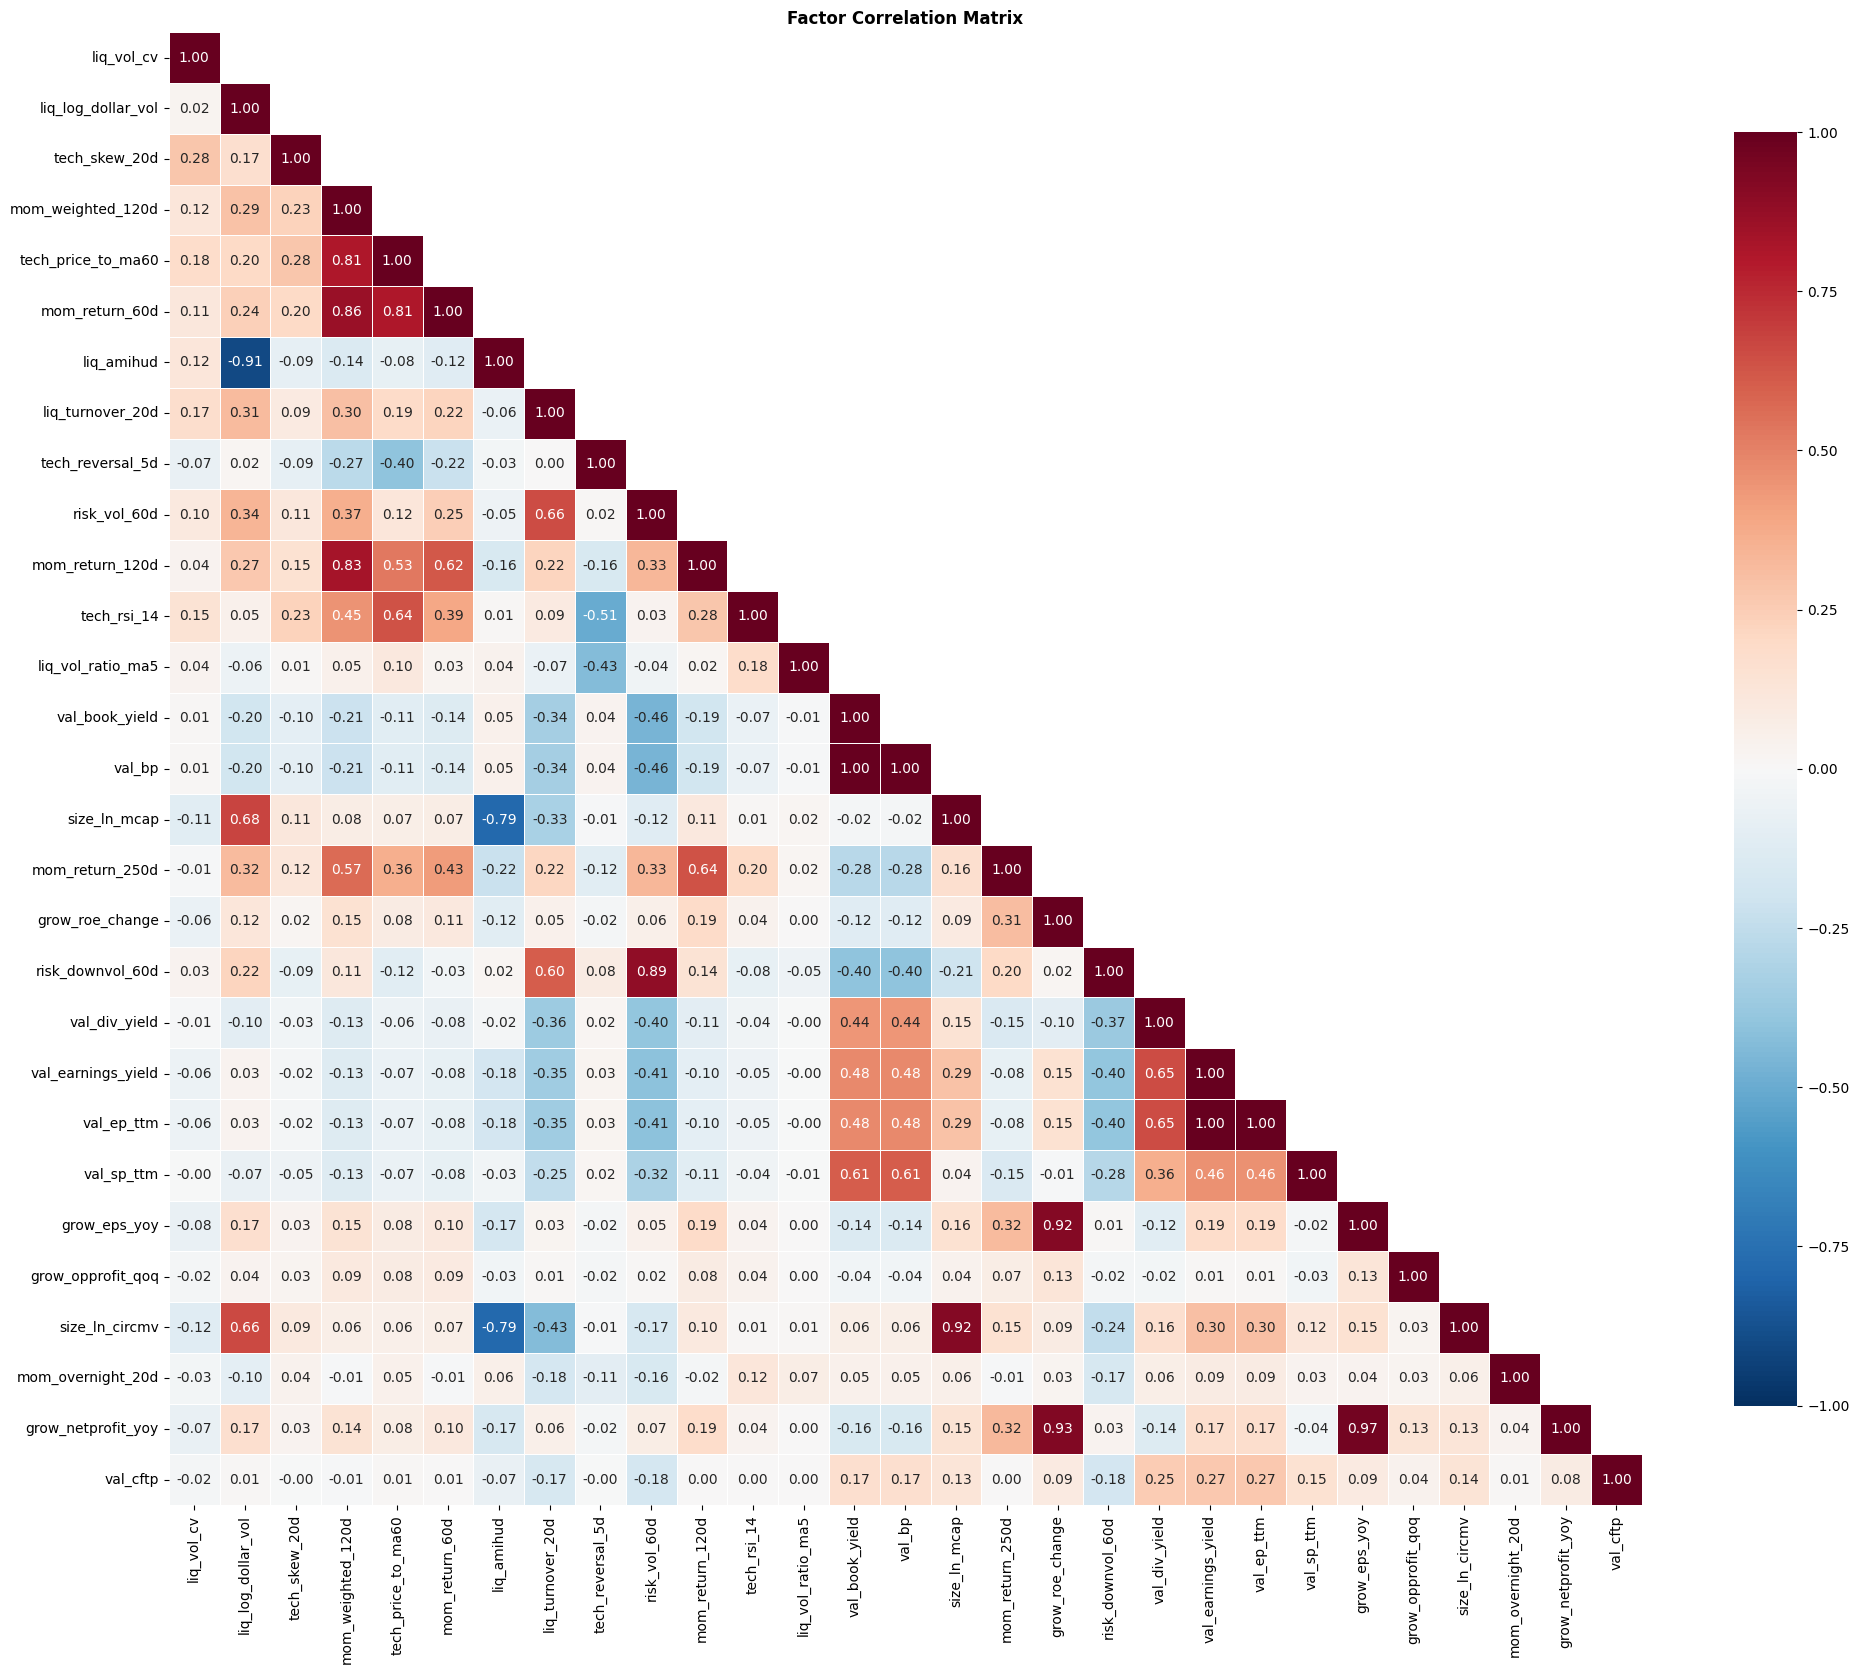


⚠️  Redundant pairs (|corr| >= 0.7):
  val_book_yield <-> val_bp: 1.000
  val_earnings_yield <-> val_ep_ttm: 1.000
  grow_eps_yoy <-> grow_netprofit_yoy: 0.966
  grow_roe_change <-> grow_netprofit_yoy: 0.929
  grow_roe_change <-> grow_eps_yoy: 0.920
  size_ln_mcap <-> size_ln_circmv: 0.919
  liq_log_dollar_vol <-> liq_amihud: -0.906
  risk_vol_60d <-> risk_downvol_60d: 0.890
  mom_weighted_120d <-> mom_return_60d: 0.861
  mom_weighted_120d <-> mom_return_120d: 0.834
  mom_weighted_120d <-> tech_price_to_ma60: 0.810
  tech_price_to_ma60 <-> mom_return_60d: 0.806
  liq_amihud <-> size_ln_circmv: -0.788
  liq_amihud <-> size_ln_mcap: -0.785


In [ ]:
from src.alpha_research.factor_eval import (
    compute_factor_correlation, find_redundant_pairs, select_uncorrelated
)

# Use graduated + questioned factors for correlation analysis
corr_factors = {}
for name in list(graduated.index) + list(questioned.index):
    if name in factors:
        corr_factors[name] = factors[name]

if len(corr_factors) >= 2:
    corr_matrix = compute_factor_correlation(corr_factors, method='spearman', min_obs=100)
    redundant = find_redundant_pairs(corr_matrix, threshold=0.7)

    from src.alpha_research.factor_eval.factor_plotters import plot_factor_correlation_heatmap
    fig, ax = plt.subplots(figsize=(max(8, len(corr_factors)*0.7), max(6, len(corr_factors)*0.6)))
    plot_factor_correlation_heatmap(corr_matrix, ax=ax)
    plt.tight_layout()
    plt.show()

    if redundant:
        print('\n⚠️  Redundant pairs (|corr| >= 0.7):')
        for a, b, c in redundant:
            print(f'  {a} <-> {b}: {c:.3f}')
    else:
        print('\n✅ No highly redundant pairs found.')
else:
    print('Not enough factors for correlation analysis.')

## 9. Rolling IC Time-Series

12-month rolling Rank IC and ICIR for Tier 1 factors.
Reveals regime shifts, factor crowding, and decay over time.

In [ ]:
%%time
from src.alpha_research.factor_eval import compute_rolling_ic

# Select Tier 1 factors (|Rank ICIR| >= 0.35)
tier1 = ic_df[ic_df['rank_icir'].abs() >= 0.35].index.tolist()
print(f'Tier 1 factors ({len(tier1)}): {tier1}')

# Compute rolling IC for each Tier 1 factor
rolling_data = {}
for name in tier1:
    ic = compute_ic_series(factors[name], fwd_5d, min_obs=50)
    if not ic.empty:
        rolling_data[name] = compute_rolling_ic(ic, window=252)
print(f'Rolling IC computed for {len(rolling_data)} factors')

Tier 1 factors (8): ['liq_vol_cv', 'liq_log_dollar_vol', 'tech_skew_20d', 'mom_weighted_120d', 'tech_price_to_ma60', 'mom_return_20d', 'risk_vol_20d', 'liq_turnover_ratio']
Rolling IC computed for 8 factors
CPU times: total: 23.6 s
Wall time: 23.7 s


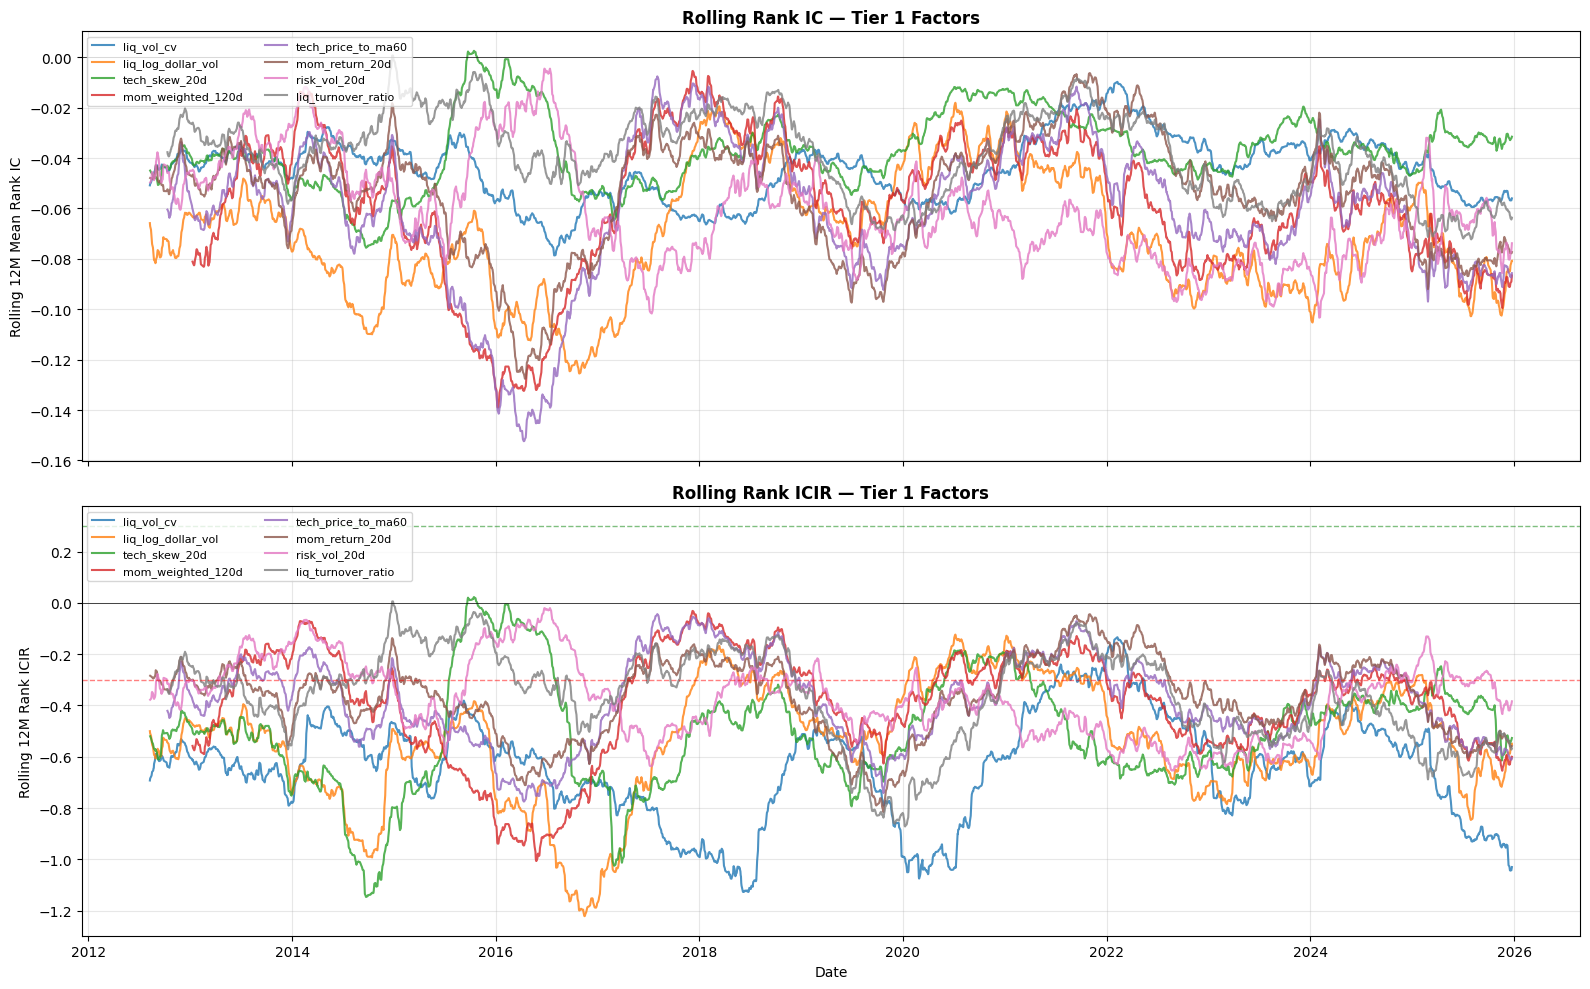

In [ ]:
# Rolling Rank IC curves
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel 1: Rolling Mean Rank IC
ax1 = axes[0]
for name, rdf in rolling_data.items():
    ax1.plot(rdf.index, rdf['rolling_mean_rank_ic'], label=name, alpha=0.8)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_ylabel('Rolling 12M Mean Rank IC')
ax1.set_title('Rolling Rank IC — Tier 1 Factors', fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, ncol=2)
ax1.grid(alpha=0.3)

# Panel 2: Rolling Rank ICIR
ax2 = axes[1]
for name, rdf in rolling_data.items():
    ax2.plot(rdf.index, rdf['rolling_rank_icir'], label=name, alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axhline(-0.3, color='red', linewidth=1, linestyle='--', alpha=0.5)
ax2.axhline(0.3, color='green', linewidth=1, linestyle='--', alpha=0.5)
ax2.set_ylabel('Rolling 12M Rank ICIR')
ax2.set_xlabel('Date')
ax2.set_title('Rolling Rank ICIR — Tier 1 Factors', fontweight='bold')
ax2.legend(loc='upper left', fontsize=8, ncol=2)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Cross-Factor Correlation & De-Redundancy

Full 43×43 Spearman correlation heatmap across all factors.
Identify redundant pairs and greedily select a diversified core pool.

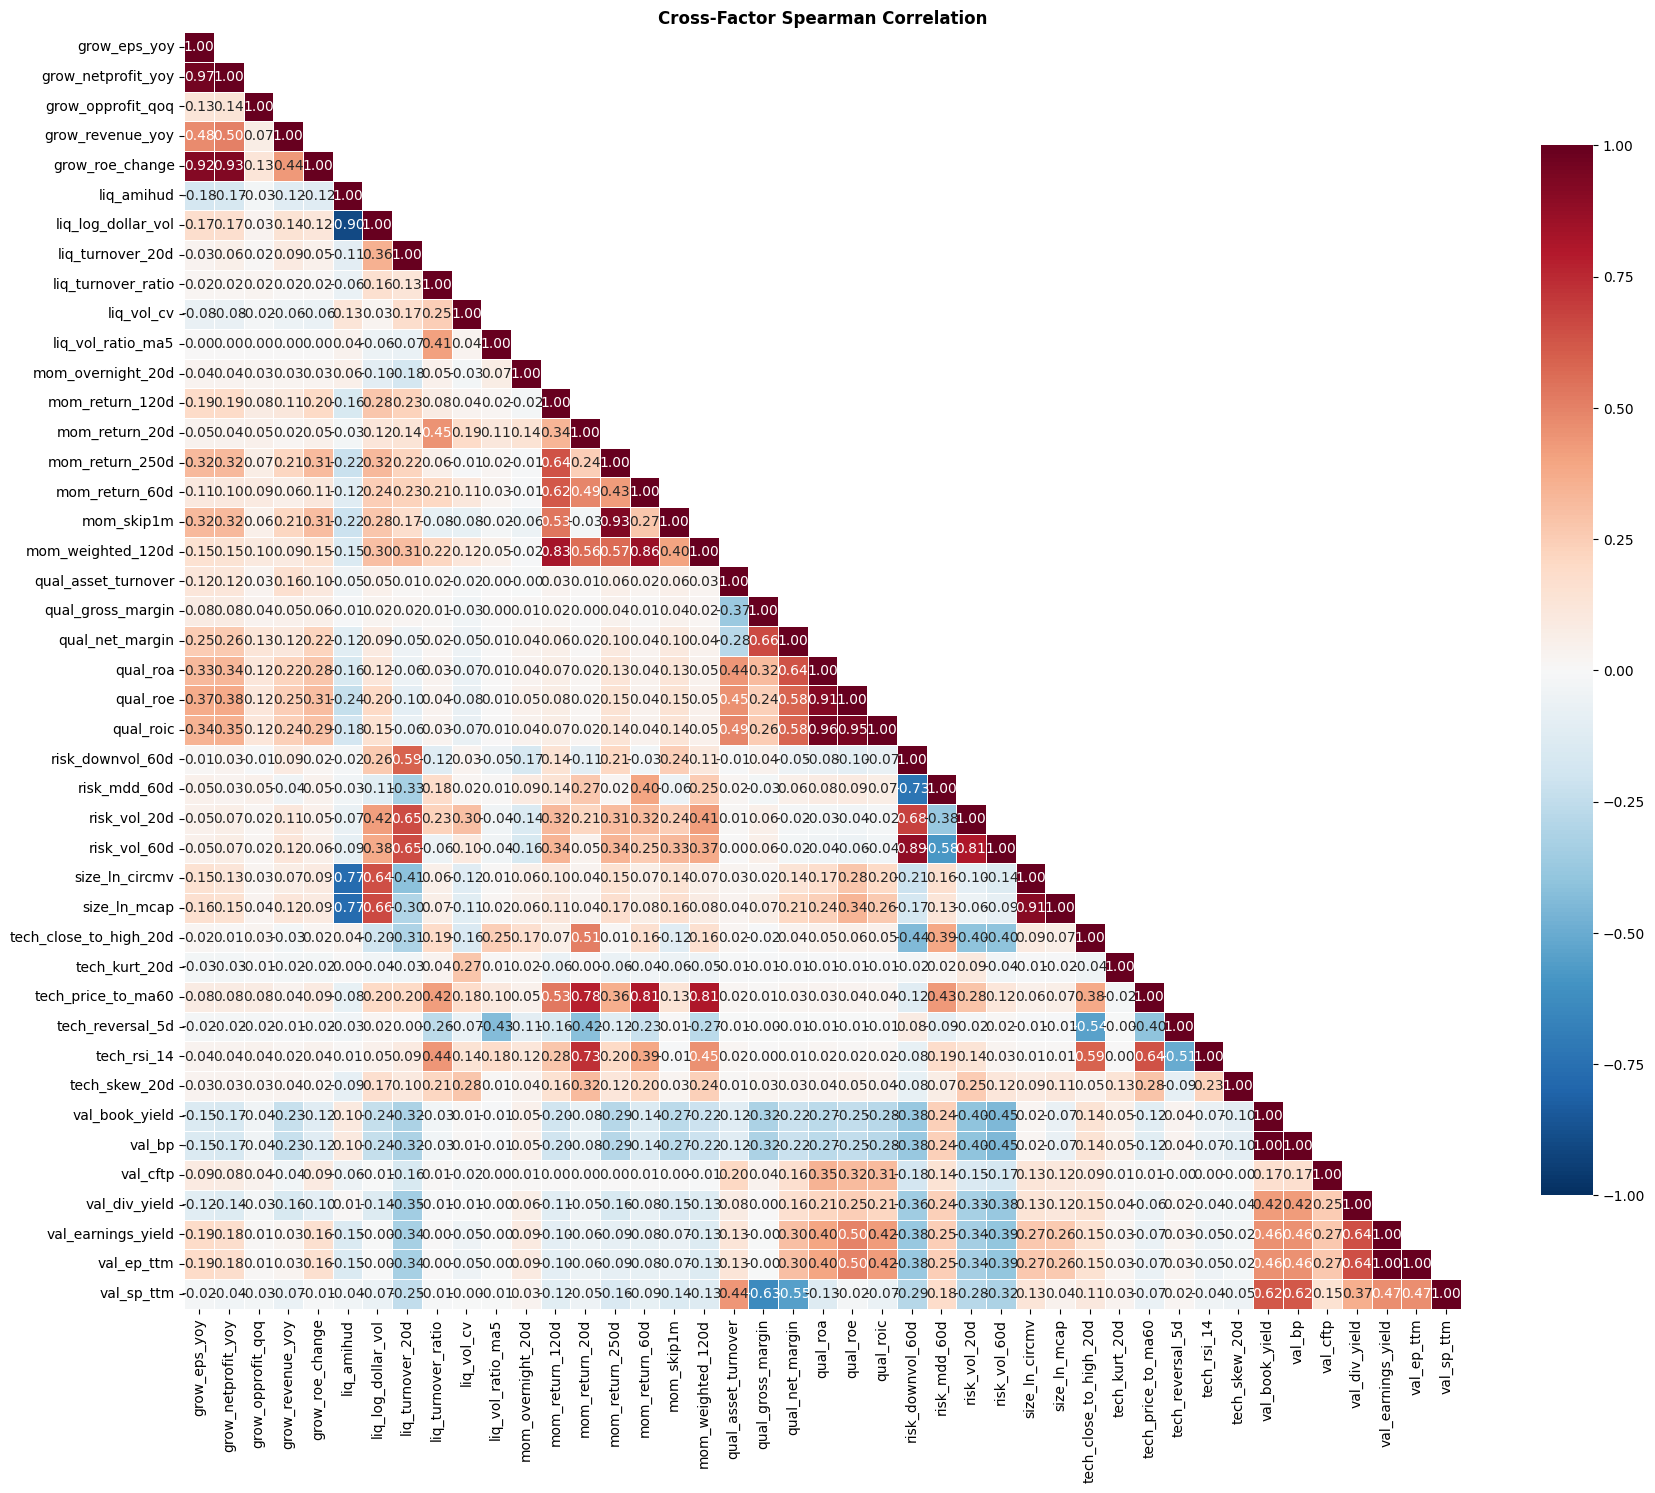

CPU times: total: 1min 10s
Wall time: 1min 10s


In [ ]:
%%time
from src.alpha_research.factor_eval import (
    compute_factor_correlation, find_redundant_pairs, select_uncorrelated
)
from src.alpha_research.factor_eval.factor_plotters import plot_factor_correlation_heatmap

# Compute full correlation matrix
all_factor_series = {name: factors[name] for name in sorted(factors.keys())}
corr_matrix = compute_factor_correlation(all_factor_series, method='spearman', min_obs=100)

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 15))
plot_factor_correlation_heatmap(corr_matrix, ax=ax, title='Cross-Factor Spearman Correlation')
plt.tight_layout()
plt.show()

In [ ]:
# Find redundant pairs (|corr| >= 0.7)
redundant = find_redundant_pairs(corr_matrix, threshold=0.7)
print(f'Redundant pairs (|corr| >= 0.7): {len(redundant)}\n')
if redundant:
    rdf = pd.DataFrame(redundant, columns=['Factor_A', 'Factor_B', 'Correlation'])
    display(rdf.style.format({'Correlation': '{:.3f}'}))

# Greedy selection of uncorrelated factors
ic_summary_all = {name: ic_results[name] for name in ic_results}
core_pool = select_uncorrelated(corr_matrix, ic_summary_all, max_corr=0.5)

print(f'\nCore factor pool ({len(core_pool)} factors, max_corr=0.5):')
for i, name in enumerate(core_pool, 1):
    icir = ic_results[name]['rank_icir']
    print(f'  {i:2d}. {name:<25s}  Rank ICIR = {icir:.3f}')

Redundant pairs (|corr| >= 0.7): 22



,Factor_A,Factor_B,Correlation
0,val_book_yield,val_bp,1.000
1,val_earnings_yield,val_ep_ttm,1.000
2,grow_eps_yoy,grow_netprofit_yoy,0.966
3,qual_roa,qual_roic,0.962
4,qual_roe,qual_roic,0.948
5,mom_return_250d,mom_skip1m,0.933
6,grow_netprofit_yoy,grow_roe_change,0.929
7,grow_eps_yoy,grow_roe_change,0.920
8,qual_roa,qual_roe,0.915
9,size_ln_circmv,size_ln_mcap,0.914



Core factor pool (22 factors, max_corr=0.5):
   1. liq_vol_cv                 Rank ICIR = -0.628
   2. liq_turnover_ratio         Rank ICIR = -0.354
   3. liq_log_dollar_vol         Rank ICIR = -0.505
   4. liq_vol_ratio_ma5          Rank ICIR = -0.233
   5. mom_return_20d             Rank ICIR = -0.367
   6. tech_reversal_5d           Rank ICIR = 0.294
   7. mom_return_60d             Rank ICIR = -0.324
   8. liq_turnover_20d           Rank ICIR = -0.299
   9. tech_skew_20d              Rank ICIR = -0.464
  10. mom_return_250d            Rank ICIR = -0.194
  11. tech_kurt_20d              Rank ICIR = -0.053
  12. val_bp                     Rank ICIR = 0.221
  13. risk_mdd_60d               Rank ICIR = 0.042
  14. qual_roic                  Rank ICIR = 0.035
  15. grow_opprofit_qoq          Rank ICIR = 0.142
  16. qual_gross_margin          Rank ICIR = 0.029
  17. val_div_yield              Rank ICIR = 0.163
  18. mom_overnight_20d          Rank ICIR = 0.138
  19. grow_revenue_yoy    

## 11. Marginal IC Contribution

Starting from the strongest factor, iteratively add factors from the core pool
and measure the incremental (marginal) IC each one contributes beyond those
already selected. Factors with near-zero marginal IC are redundant in context.

In [ ]:
%%time
from src.alpha_research.factor_eval import compute_marginal_ic

# Use core_pool ordering (already sorted by |ICIR| descending)
marginal_results = []
selected_so_far = []

for name in core_pool:
    _, m_summary = compute_marginal_ic(
        factors_dict=factors,
        forward_return=fwd_5d,
        base_factors=selected_so_far,
        candidate=name,
        min_obs=50,
    )
    marginal_results.append({
        'factor': name,
        'raw_rank_icir': ic_results[name]['rank_icir'],
        'marginal_rank_ic': m_summary.get('mean_rank_ic', 0),
        'marginal_rank_icir': m_summary.get('rank_icir', 0),
        'step': len(selected_so_far) + 1,
    })
    selected_so_far.append(name)
    print(f'  Step {len(selected_so_far)}: +{name}  marginal ICIR={m_summary.get("rank_icir", 0):.3f}')

marginal_df = pd.DataFrame(marginal_results).set_index('factor')
display(marginal_df.style.format({
    'raw_rank_icir': '{:.3f}', 'marginal_rank_ic': '{:.4f}',
    'marginal_rank_icir': '{:.3f}',
}))

  Step 1: +liq_vol_cv  marginal ICIR=-0.628
  Step 2: +liq_turnover_ratio  marginal ICIR=-0.234
  Step 3: +liq_log_dollar_vol  marginal ICIR=-0.455
  Step 4: +liq_vol_ratio_ma5  marginal ICIR=-0.089
  Step 5: +mom_return_20d  marginal ICIR=-0.220
  Step 6: +tech_reversal_5d  marginal ICIR=0.203
  Step 7: +mom_return_60d  marginal ICIR=-0.009
  Step 8: +liq_turnover_20d  marginal ICIR=-0.121
  Step 9: +tech_skew_20d  marginal ICIR=-0.210
  Step 10: +mom_return_250d  marginal ICIR=0.162
  Step 11: +tech_kurt_20d  marginal ICIR=0.072
  Step 12: +val_bp  marginal ICIR=0.103
  Step 13: +risk_mdd_60d  marginal ICIR=0.099
  Step 14: +qual_roic  marginal ICIR=0.179
  Step 15: +grow_opprofit_qoq  marginal ICIR=0.077
  Step 16: +qual_gross_margin  marginal ICIR=0.031
  Step 17: +val_div_yield  marginal ICIR=-0.094
  Step 18: +mom_overnight_20d  marginal ICIR=0.338
  Step 19: +grow_revenue_yoy  marginal ICIR=0.179
  Step 20: +qual_asset_turnover  marginal ICIR=0.063
  Step 21: +grow_eps_yoy  marg

,raw_rank_icir,marginal_rank_ic,marginal_rank_icir,step
factor,,,,
liq_vol_cv,-0.628,-0.0445,-0.628,1
liq_turnover_ratio,-0.354,-0.0234,-0.234,2
liq_log_dollar_vol,-0.505,-0.0632,-0.455,3
liq_vol_ratio_ma5,-0.233,-0.0069,-0.089,4
mom_return_20d,-0.367,-0.0267,-0.220,5
tech_reversal_5d,0.294,0.0200,0.203,6
mom_return_60d,-0.324,-0.0011,-0.009,7
liq_turnover_20d,-0.299,-0.0172,-0.121,8
tech_skew_20d,-0.464,-0.0105,-0.210,9


CPU times: total: 4min 49s
Wall time: 4min 52s


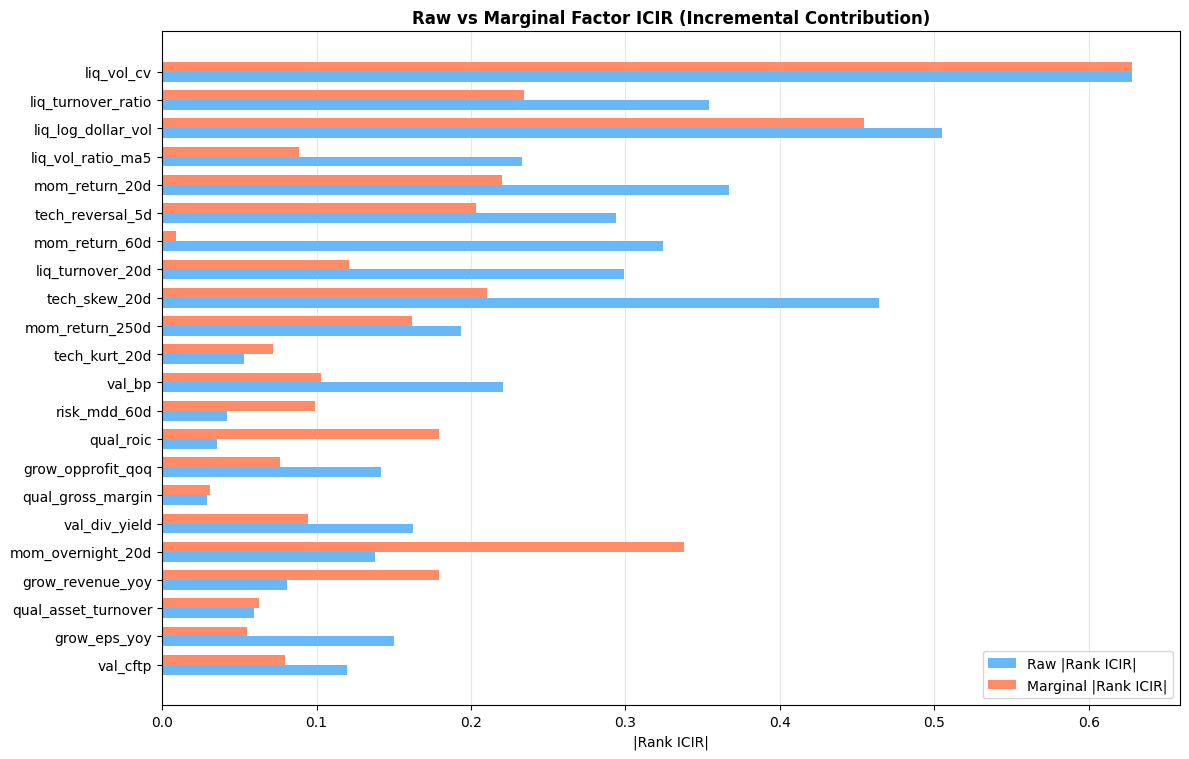

In [ ]:
# Bar chart: Raw ICIR vs Marginal ICIR
fig, ax = plt.subplots(figsize=(12, max(5, len(marginal_df) * 0.35)))
y_pos = np.arange(len(marginal_df))
bar_height = 0.35

ax.barh(y_pos + bar_height/2, marginal_df['raw_rank_icir'].abs(),
        height=bar_height, label='Raw |Rank ICIR|', color='#42A5F5', alpha=0.8)
ax.barh(y_pos - bar_height/2, marginal_df['marginal_rank_icir'].abs(),
        height=bar_height, label='Marginal |Rank ICIR|', color='#FF7043', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(marginal_df.index)
ax.set_xlabel('|Rank ICIR|')
ax.set_title('Raw vs Marginal Factor ICIR (Incremental Contribution)', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Size-Group Sub-Analysis

Test whether the top factors work across all market cap segments.
Stocks are split into Large / Mid / Small terciles by `total_mv` each day.

In [ ]:
%%time
from src.alpha_research.factor_eval import compute_ic_by_group

# Create size tercile labels
total_mv = df_market['total_mv']
size_labels = total_mv.groupby(level=0).transform(
    lambda x: pd.qcut(x, 3, labels=['Small', 'Mid', 'Large'], duplicates='drop')
)
size_labels.name = 'size_group'

# Analyze Tier 1+2 factors (|Rank ICIR| >= 0.2)
tier12 = ic_df[ic_df['rank_icir'].abs() >= 0.2].index.tolist()
print(f'Analyzing {len(tier12)} factors across size groups...\n')

size_group_results = []
for name in tier12:
    group_ic = compute_ic_by_group(factors[name], fwd_5d, size_labels, min_obs=30)
    for grp, summary in group_ic.items():
        size_group_results.append({
            'factor': name,
            'size_group': grp,
            'mean_rank_ic': summary['mean_rank_ic'],
            'rank_icir': summary['rank_icir'],
            'n_days': summary['n_days'],
        })

sg_df = pd.DataFrame(size_group_results)
print(f'Results collected: {len(sg_df)} rows')

Analyzing 18 factors across size groups...

Results collected: 54 rows
CPU times: total: 1min 44s
Wall time: 1min 45s


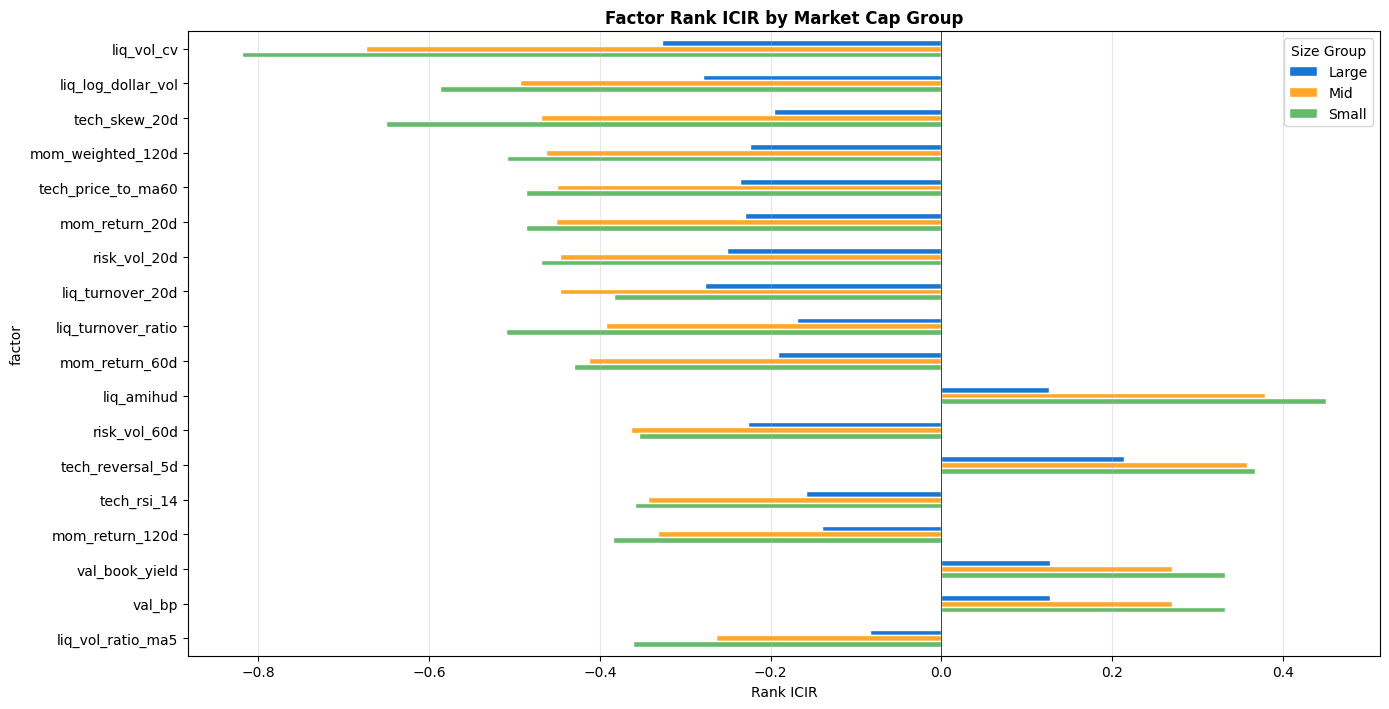


Universality check (factors effective across all size groups):
  liq_vol_cv                ✅ Universal  avg|ICIR|=0.607
  liq_log_dollar_vol        ✅ Universal  avg|ICIR|=0.453
  tech_skew_20d             ✅ Universal  avg|ICIR|=0.439
  mom_weighted_120d         ✅ Universal  avg|ICIR|=0.399
  tech_price_to_ma60        ✅ Universal  avg|ICIR|=0.391
  mom_return_20d            ✅ Universal  avg|ICIR|=0.389
  risk_vol_20d              ✅ Universal  avg|ICIR|=0.389
  liq_turnover_20d          ✅ Universal  avg|ICIR|=0.369
  liq_turnover_ratio        ✅ Universal  avg|ICIR|=0.357
  mom_return_60d            ✅ Universal  avg|ICIR|=0.345
  liq_amihud                ✅ Universal  avg|ICIR|=0.318
  risk_vol_60d              ✅ Universal  avg|ICIR|=0.315
  tech_reversal_5d          ✅ Universal  avg|ICIR|=0.313
  tech_rsi_14               ✅ Universal  avg|ICIR|=0.287
  mom_return_120d           ✅ Universal  avg|ICIR|=0.285
  val_book_yield            ✅ Universal  avg|ICIR|=0.243
  val_bp                

In [ ]:
# Grouped bar chart: Rank ICIR by size group
if not sg_df.empty:
    pivot = sg_df.pivot(index='factor', columns='size_group', values='rank_icir')
    # Reorder columns
    cols = [c for c in ['Large', 'Mid', 'Small'] if c in pivot.columns]
    pivot = pivot[cols]
    # Sort by average |ICIR|
    pivot = pivot.loc[pivot.abs().mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.4)))
    pivot.plot.barh(ax=ax, color=['#1976D2', '#FFA726', '#66BB6A'], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Rank ICIR')
    ax.set_title('Factor Rank ICIR by Market Cap Group', fontweight='bold')
    ax.legend(title='Size Group')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Summary table
    print('\nUniversality check (factors effective across all size groups):')
    for name in pivot.index:
        vals = pivot.loc[name].dropna()
        all_same_sign = (vals > 0).all() or (vals < 0).all()
        avg = vals.abs().mean()
        status = '✅ Universal' if all_same_sign and avg > 0.15 else '⚠️  Partial' if all_same_sign else '❌ Inconsistent'
        print(f'  {name:<25s} {status}  avg|ICIR|={avg:.3f}')
else:
    print('No size-group results available.')

## 13. Long-Short Portfolio Backtest

For each core-pool factor, build quintile long-short portfolios and compare
equity curves, Sharpe ratios, max drawdown, and annual returns.

> **Note:** These are paper portfolios assuming equal-weight, daily rebalance,
> zero transaction cost. Real-world performance will differ.

In [ ]:
%%time
from src.result_analysis.metrics import generate_performance_report

# Build L/S portfolios for core pool factors
ls_curves = {}
ls_stats = []

for name in core_pool:
    q_ret = compute_quantile_returns(factors[name], fwd_5d, n_quantiles=5, min_obs=100)
    if q_ret.empty:
        continue
    q_sum = compute_quantile_summary(q_ret)
    mono = test_monotonicity(q_sum)

    # Determine long/short direction based on factor sign
    rank_icir = ic_results[name]['rank_icir']
    if rank_icir > 0:
        long_q, short_q = q_ret['quantile'].max(), 1
    else:
        long_q, short_q = 1, q_ret['quantile'].max()

    ls = compute_long_short_returns(q_ret, long_q=long_q, short_q=short_q)
    if ls.empty:
        continue

    ls_curves[name] = ls
    cum_ret = (1 + ls).cumprod()

    report = generate_performance_report(ls)
    ls_stats.append({
        'factor': name,
        'direction': 'long_high' if rank_icir > 0 else 'long_low',
        'ann_return': float(report.loc['Annualized Return', 'Strategy']),
        'volatility': float(report.loc['Annualized Volatility', 'Strategy']),
        'sharpe': float(report.loc['Sharpe Ratio', 'Strategy']),
        'max_drawdown': float(report.loc['Max Drawdown', 'Strategy']),
        'win_rate': float(report.loc['Win Rate', 'Strategy']),
        'monotonic': mono['is_monotonic'],
    })

ls_stat_df = pd.DataFrame(ls_stats).set_index('factor')
ls_stat_df = ls_stat_df.sort_values('sharpe', ascending=False)

print(f'L/S backtest completed for {len(ls_stat_df)} factors\n')
display(ls_stat_df.style.format({
    'ann_return': '{:.2%}', 'volatility': '{:.2%}',
    'sharpe': '{:.3f}', 'max_drawdown': '{:.2%}', 'win_rate': '{:.1%}',
}).background_gradient(subset=['sharpe'], cmap='RdYlGn', vmin=-0.5, vmax=1.5))

L/S backtest completed for 22 factors



,direction,ann_return,volatility,sharpe,max_drawdown,win_rate,monotonic
factor,,,,,,,
liq_vol_cv,long_low,176.30%,18.10%,5.715,-36.92%,68.1%,True
liq_log_dollar_vol,long_low,384.45%,34.61%,4.747,-69.55%,65.5%,True
mom_return_20d,long_low,220.58%,38.72%,3.204,-68.98%,58.1%,False
mom_return_60d,long_low,197.30%,40.38%,2.903,-68.80%,58.0%,True
tech_skew_20d,long_low,73.86%,20.25%,2.836,-87.96%,61.5%,True
tech_reversal_5d,long_high,144.67%,34.39%,2.775,-46.08%,58.2%,False
liq_turnover_ratio,long_low,90.58%,27.25%,2.506,-65.39%,59.4%,False
grow_opprofit_qoq,long_high,22.76%,9.46%,2.215,-46.72%,54.7%,True
liq_turnover_20d,long_low,108.32%,42.62%,1.937,-77.57%,54.6%,False


CPU times: total: 2min 43s
Wall time: 2min 45s


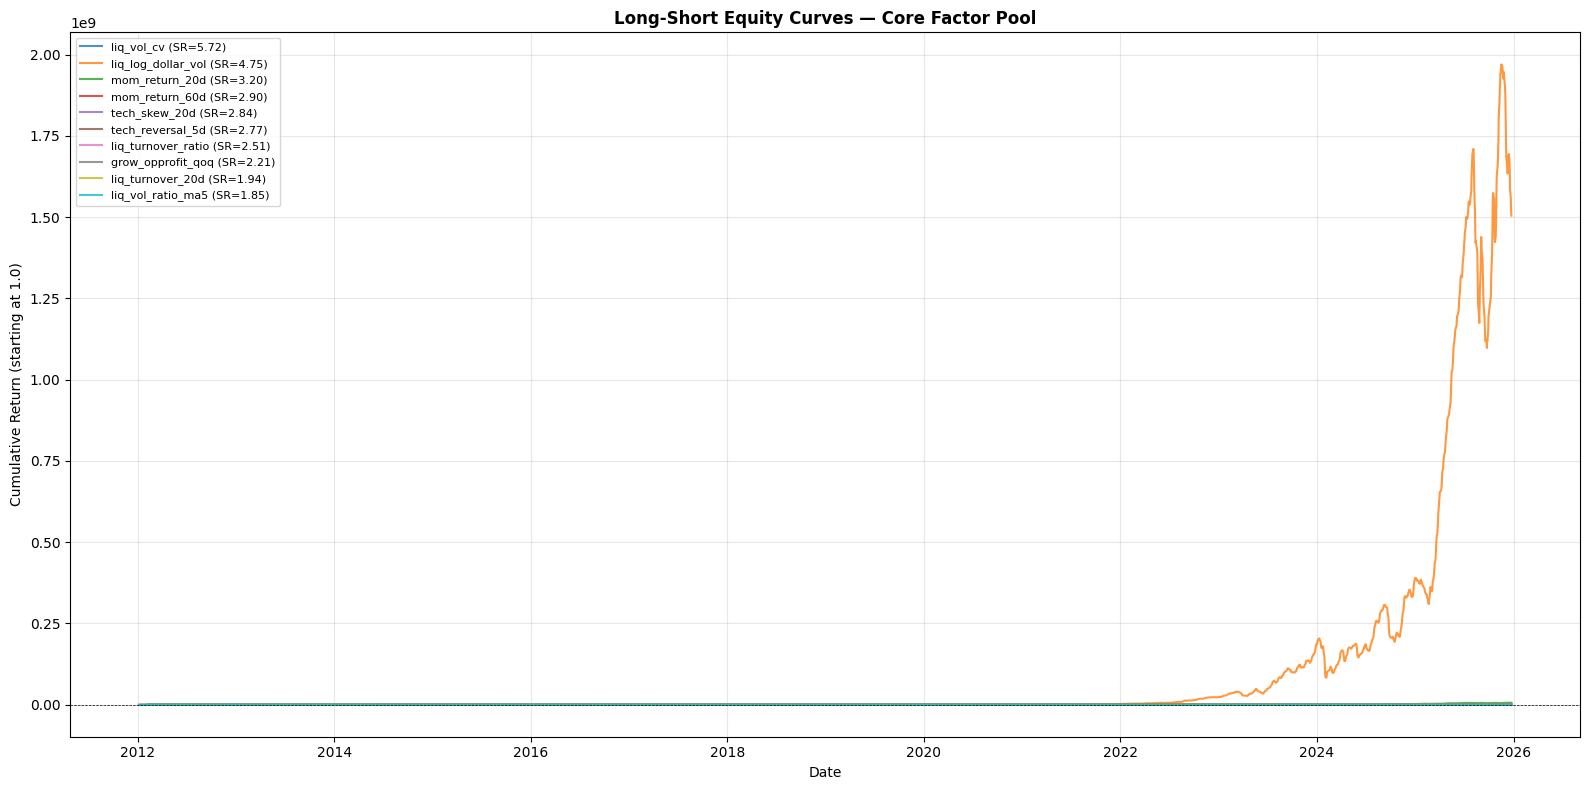

In [ ]:
# Equity curves
fig, ax = plt.subplots(figsize=(16, 8))

for name in ls_stat_df.index[:10]:  # Top 10 by Sharpe
    if name in ls_curves:
        cum = (1 + ls_curves[name]).cumprod()
        sharpe = ls_stat_df.loc[name, 'sharpe']
        ax.plot(cum.index, cum.values, label=f'{name} (SR={sharpe:.2f})', alpha=0.8)

ax.axhline(1, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('Cumulative Return (starting at 1.0)')
ax.set_xlabel('Date')
ax.set_title('Long-Short Equity Curves — Core Factor Pool', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Factor Pool Summary

Final recommended factor list after de-redundancy, with comprehensive
per-factor diagnostics.

In [ ]:
# Build final factor scorecard
scorecard = []
for name in core_pool:
    ic_s = ic_results.get(name, {})
    ls_s = ls_stat_df.loc[name] if name in ls_stat_df.index else pd.Series()

    # Check size universality
    factor_sg = sg_df[sg_df['factor'] == name] if name in sg_df['factor'].values else pd.DataFrame()
    if not factor_sg.empty:
        sg_icirs = factor_sg.set_index('size_group')['rank_icir']
        universal = (sg_icirs > 0).all() or (sg_icirs < 0).all()
    else:
        universal = None

    scorecard.append({
        'factor': name,
        'category': name.split('_')[0],
        'direction': '📈 Long High' if ic_s.get('rank_icir', 0) > 0 else '📉 Long Low',
        'rank_icir': ic_s.get('rank_icir', 0),
        'ic_hit_rate': ic_s.get('ic_hit_rate', 0),
        'ls_sharpe': ls_s.get('sharpe', 0) if not ls_s.empty else 0,
        'ls_ann_return': ls_s.get('ann_return', 0) if not ls_s.empty else 0,
        'max_drawdown': ls_s.get('max_drawdown', 0) if not ls_s.empty else 0,
        'size_universal': '✅' if universal else ('❌' if universal is False else '—'),
    })

score_df = pd.DataFrame(scorecard).set_index('factor')

print(f'═══ FINAL FACTOR POOL: {len(score_df)} factors ═══\n')
display(score_df.style.format({
    'rank_icir': '{:.3f}', 'ic_hit_rate': '{:.1%}',
    'ls_sharpe': '{:.3f}', 'ls_ann_return': '{:.2%}',
    'max_drawdown': '{:.2%}',
}).background_gradient(subset=['rank_icir'], cmap='RdYlGn', vmin=-0.5, vmax=0.5))

═══ FINAL FACTOR POOL: 22 factors ═══



,category,direction,rank_icir,ic_hit_rate,ls_sharpe,ls_ann_return,max_drawdown,size_universal
factor,,,,,,,,
liq_vol_cv,liq,📉 Long Low,-0.628,72.1%,5.715,176.30%,-36.92%,✅
liq_turnover_ratio,liq,📉 Long Low,-0.354,65.7%,2.506,90.58%,-65.39%,✅
liq_log_dollar_vol,liq,📉 Long Low,-0.505,65.4%,4.747,384.45%,-69.55%,✅
liq_vol_ratio_ma5,liq,📉 Long Low,-0.233,65.4%,1.852,42.79%,-57.82%,✅
mom_return_20d,mom,📉 Long Low,-0.367,60.6%,3.204,220.58%,-68.98%,✅
tech_reversal_5d,tech,📈 Long High,0.294,61.2%,2.775,144.67%,-46.08%,✅
mom_return_60d,mom,📉 Long Low,-0.324,59.4%,2.903,197.30%,-68.80%,✅
liq_turnover_20d,liq,📉 Long Low,-0.299,59.5%,1.937,108.32%,-77.57%,✅
tech_skew_20d,tech,📉 Long Low,-0.464,58.6%,2.836,73.86%,-87.96%,✅


In [ ]:
# Category breakdown
print('Factor pool by category:')
cat_counts = score_df['category'].value_counts()
for cat, cnt in cat_counts.items():
    cat_factors = score_df[score_df['category'] == cat].index.tolist()
    print(f'  {cat}: {cnt} factors — {", ".join(cat_factors)}')

print(f'\nTotal factors in final pool: {len(score_df)}')
print(f'Avg |Rank ICIR|: {score_df["rank_icir"].abs().mean():.3f}')
print(f'Avg L/S Sharpe: {score_df["ls_sharpe"].mean():.3f}')
print(f'Size-universal factors: {(score_df["size_universal"] == "✅").sum()} / {len(score_df)}')

Factor pool by category:
  liq: 5 factors — liq_vol_cv, liq_turnover_ratio, liq_log_dollar_vol, liq_vol_ratio_ma5, liq_turnover_20d
  mom: 4 factors — mom_return_20d, mom_return_60d, mom_return_250d, mom_overnight_20d
  tech: 3 factors — tech_reversal_5d, tech_skew_20d, tech_kurt_20d
  val: 3 factors — val_bp, val_div_yield, val_cftp
  qual: 3 factors — qual_roic, qual_gross_margin, qual_asset_turnover
  grow: 3 factors — grow_opprofit_qoq, grow_revenue_yoy, grow_eps_yoy
  risk: 1 factors — risk_mdd_60d

Total factors in final pool: 22
Avg |Rank ICIR|: 0.222
Avg L/S Sharpe: 1.749
Size-universal factors: 10 / 22


## 15. Next Steps

1. **Neutralization**: Run `neutralize_size_industry()` on core-pool factors
2. **Decay analysis**: Use `compute_ic_decay()` to find optimal holding period
3. **Composite factor**: Combine core-pool factors via ICIR-weighted z-score
4. **Validation period**: Re-run on 2021-2023 data separately
5. **Out-of-sample test**: Run ONCE on 2024+ (do not iterate on test results)
6. **Backtest**: Use `VectorizedBacktester` with TopkDropout strategy
7. **MLflow**: Log all results via `ExperimentTracker`

---
*Generated by `workspace/scripts/generate_factor_notebook.py`*